# Example-18: Non-uniform sampling

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

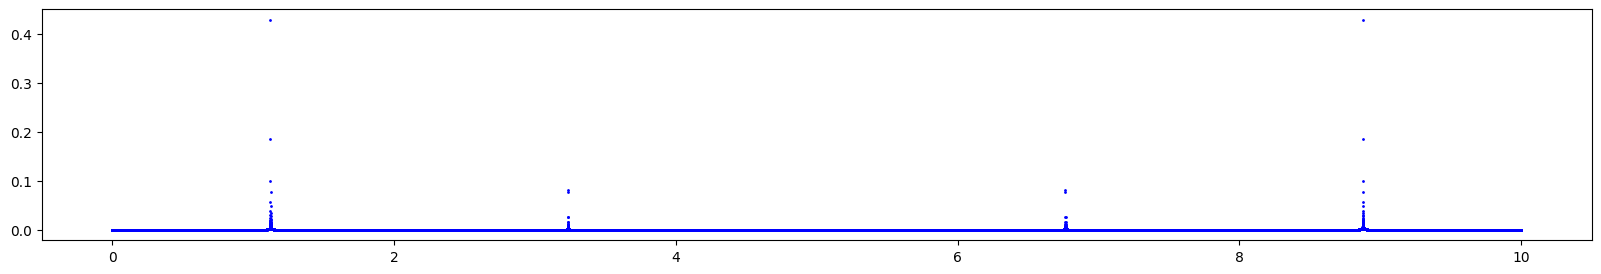

In [3]:
# Uniform sampling (stationary)

r = 10
l = 8192
t = torch.linspace(0.0, 1.0-1.0/r, r, dtype=torch.float64, device=torch.device('cpu'))
t = torch.cat([t + i for i in range(l)])

a = [1.0, 0.25]
f = [1.12345, 3.23456]
s = torch.sum(torch.stack([a[i]*torch.cos(2.0*numpy.pi*f[i]*t) for i in range(len(f))]), 0)

f_min, f_max = 0.0, 10.0
grid = 2.0*numpy.pi*numpy.linspace(f_min, f_max, len(t) + 1)
data = nufft.nufft1d3(t, s, grid)

plt.figure(figsize=(20, 3))
plt.scatter(grid/(2.0*numpy.pi), numpy.abs(data), c='b', s=1)
plt.show()

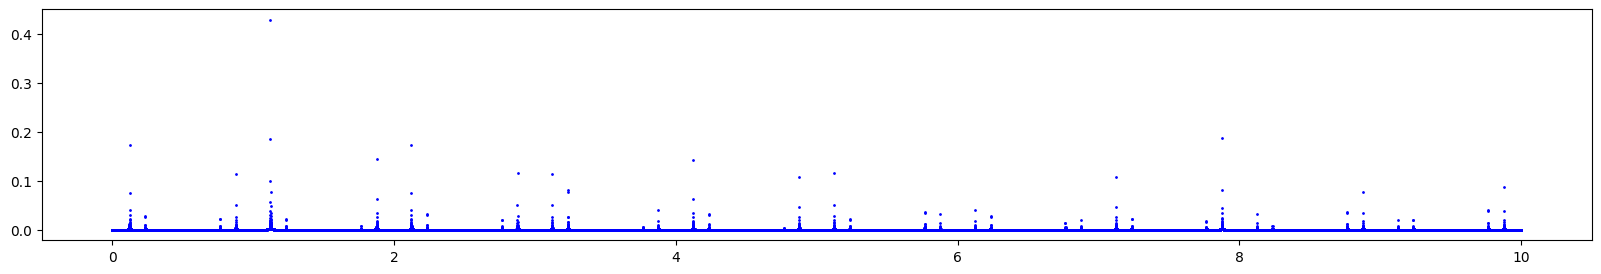

In [4]:
# Non-uniform periodic sampling (stationary)

r = 10
l = 8192
t = torch.sort(torch.rand(r, dtype=torch.float64, device=torch.device('cpu'))).values
t = torch.cat([t + i for i in range(l)])

a = [1.0, 0.25]
f = [1.12345, 3.23456]
s = torch.sum(torch.stack([a[i]*torch.cos(2.0*numpy.pi*f[i]*t) for i in range(len(f))]), 0)

f_min, f_max = 0.0, 10.0
grid = 2.0*numpy.pi*numpy.linspace(f_min, f_max, len(t) + 1)
data = nufft.nufft1d3(t, s, grid)

plt.figure(figsize=(20, 3))
plt.scatter(grid/(2.0*numpy.pi), numpy.abs(data), c='b', s=1)
plt.show()

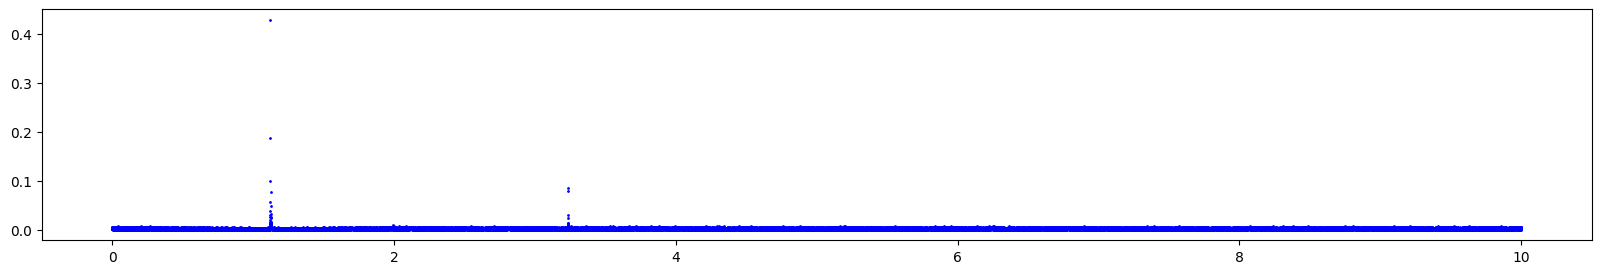

In [5]:
# Non-uniform random sampling (stationary)

r = 10
l = 8192
t = torch.cat([torch.sort(torch.rand(r, dtype=torch.float64, device=torch.device('cpu'))).values + i for i in range(l)])

a = [1.0, 0.25]
f = [1.12345, 3.23456]
s = torch.sum(torch.stack([a[i]*torch.cos(2.0*numpy.pi*f[i]*t) for i in range(len(f))]), 0)

f_min, f_max = 0.0, 10.0
grid = 2.0*numpy.pi*numpy.linspace(f_min, f_max, len(t) + 1)
data = nufft.nufft1d3(t, s, grid)

plt.figure(figsize=(20, 3))
plt.scatter(grid/(2.0*numpy.pi), numpy.abs(data), c='b', s=1)
plt.show()

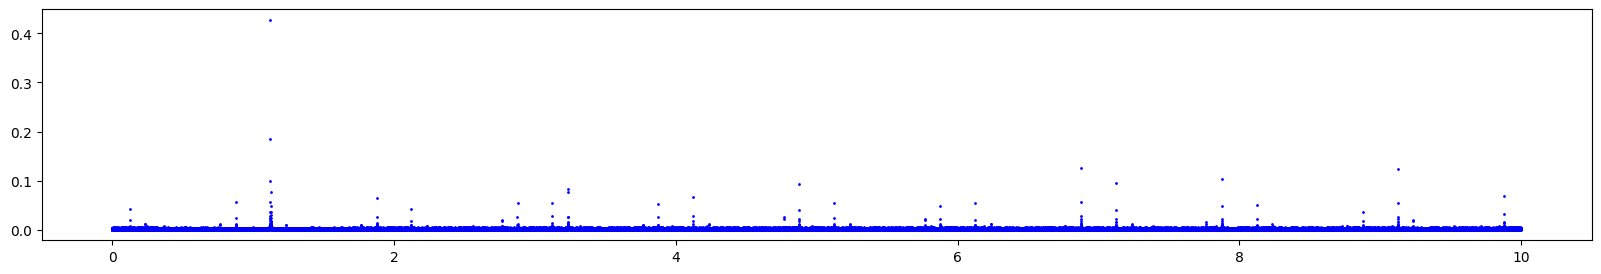

In [6]:
# Non-uniform periodic sampling with random choice (stationary)

c = 10
r = 5*10
l = 8192
t = torch.sort(torch.rand(r, dtype=torch.float64, device=torch.device('cpu'))).values
w = range(r)
t = torch.cat([torch.sort(t[numpy.random.choice(w, size=c, replace=False)]).values + i for i in range(l)])

a = [1.0, 0.25]
f = [1.12345, 3.23456]
s = torch.sum(torch.stack([a[i]*torch.cos(2.0*numpy.pi*f[i]*t) for i in range(len(f))]), 0)

f_min, f_max = 0.0, 10.0
grid = 2.0*numpy.pi*numpy.linspace(f_min, f_max, len(t) + 1)
data = nufft.nufft1d3(t, s, grid)

plt.figure(figsize=(20, 3))
plt.scatter(grid/(2.0*numpy.pi), numpy.abs(data), c='b', s=1)
plt.show()